# Step 1: Data Collection and Understanding

In [2]:
import pandas as pd
import yfinance as yf

# Download Stock Data

ticker = "RELIANCE.NS"

data = yf.download(
    ticker,
    start="2020-01-01",
    interval="1d",
    auto_adjust=False
)

# Flatten MultiIndex Columns

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Save Raw Dataset

data.to_csv("nse_ohlcv_raw.csv")

# Load Dataset

data = pd.read_csv("nse_ohlcv_raw.csv")

# Data Understanding

print("\nFirst 5 Rows")
print(data.head())

print("\nLast 5 Rows")
print(data.tail())

print("\nDataset Information")
data.info()

print("\nStatistical Summary")
print(data.describe())

print("\nColumn Names")
print(data.columns.tolist())

print("\nDataset Shape")
print(data.shape)

print("\nData Types")
print(data.dtypes)

[*********************100%***********************]  1 of 1 completed


First 5 Rows
         Date   Adj Close       Close        High         Low        Open  \
0  2020-01-01  672.216187  690.138306  698.138733  688.263977  693.978516   
1  2020-01-02  683.660217  701.887512  704.470520  691.235535  691.235535   
2  2020-01-03  684.484070  702.733276  704.790527  696.264343  700.835999   
3  2020-01-06  668.609375  686.435303  698.504456  684.835205  694.892883   
4  2020-01-07  678.895569  696.995850  701.521790  691.921265  694.435669   

     Volume  
0  14004468  
1  17710316  
2  20984698  
3  24519177  
4  16683622  

Last 5 Rows
            Date    Adj Close        Close         High          Low  \
1658  2026-09-07  1309.500000  1309.500000  1324.199951  1301.900024   
1659  2026-09-08  1294.900024  1294.900024  1306.800049  1288.000000   
1660  2026-09-09  1279.000000  1279.000000  1294.699951  1277.199951   
1661  2026-09-10  1274.000000  1274.000000  1285.300049  1266.300049   
1662  2026-09-11  1257.500000  1257.500000  1267.400024  1253.0000

# Step 2: Data Preprocessing

In [3]:

# Check Missing Values

print("\nMissing Values")
print(data.isnull().sum())

# Check Duplicate Rows

print("\nDuplicate Rows")
print(data.duplicated().sum())

# Convert Date Column to Datetime

data["Date"] = pd.to_datetime(data["Date"])

# Sort Data by Date

data = data.sort_values("Date")

# Remove Missing Values

data = data.dropna()

# Remove Duplicate Rows

data = data.drop_duplicates()

# Reset Index

data = data.reset_index(drop=True)

# Verify Dataset After Cleaning

print("\nAfter Cleaning")

print("\nMissing Values")
print(data.isnull().sum())

print("\nDuplicate Rows")
print(data.duplicated().sum())

print("\nDataset Shape")
print(data.shape)

# Save Clean Dataset

data.to_csv(
    "nse_ohlcv_clean.csv",
    index=False
)




Missing Values
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows
0

After Cleaning

Missing Values
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows
0

Dataset Shape
(1663, 7)


# Step 3: Feature Engineering


In [4]:

#Candle Body
data["Body"] = abs(data["Close"] - data["Open"])

#Total Candle Range
data["Range"] = data["High"] - data["Low"]

#Upper Wick
data["Upper_Wick"] = (
    data["High"]
    - data[["Open", "Close"]].max(axis=1)
)

#Lower Wick
data["Lower_Wick"] = (
    data[["Open", "Close"]].min(axis=1)
    - data["Low"]
)

#Ratios
data["Body_Ratio"] = data["Body"] / data["Range"]

data["Upper_Wick_Ratio"] = (
    data["Upper_Wick"] / data["Range"]
)

data["Lower_Wick_Ratio"] = (
    data["Lower_Wick"] / data["Range"]
)

#Replace infinite values if any
data.replace([float("inf"), -float("inf")], 0, inplace=True)

#Fill NaN values
data.fillna(0, inplace=True)

#Display Result
print("Feature Engineering Completed\n")

print(data[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Body",
        "Range",
        "Upper_Wick",
        "Lower_Wick"
    ]
].head())

#Save Dataset
data.to_csv(
    "candlestick_features.csv",
    index=False
)


Feature Engineering Completed

         Open        High         Low       Close       Body      Range  \
0  693.978516  698.138733  688.263977  690.138306   3.840210   9.874756   
1  691.235535  704.470520  691.235535  701.887512  10.651978  13.234985   
2  700.835999  704.790527  696.264343  702.733276   1.897278   8.526184   
3  694.892883  698.504456  684.835205  686.435303   8.457581  13.669250   
4  694.435669  701.521790  691.921265  696.995850   2.560181   9.600525   

   Upper_Wick  Lower_Wick  
0    4.160217    1.874329  
1    2.583008    0.000000  
2    2.057251    4.571655  
3    3.611572    1.600098  
4    4.525940    2.514404  


# STEP 4 : MARKET STRUCTURE AND TREND ANALYSIS


Starting Market Structure Analysis...

Pivot High / Low Detection Completed
HH HL LH LL Classification Completed
Trend Direction Completed
Market Control Completed
HTF Bias Completed

Date : 2026-09-11 00:00:00
Trend : Range
Market Control : Neutral
HTF Bias : Bearish

market_structure_analysis.csv Saved


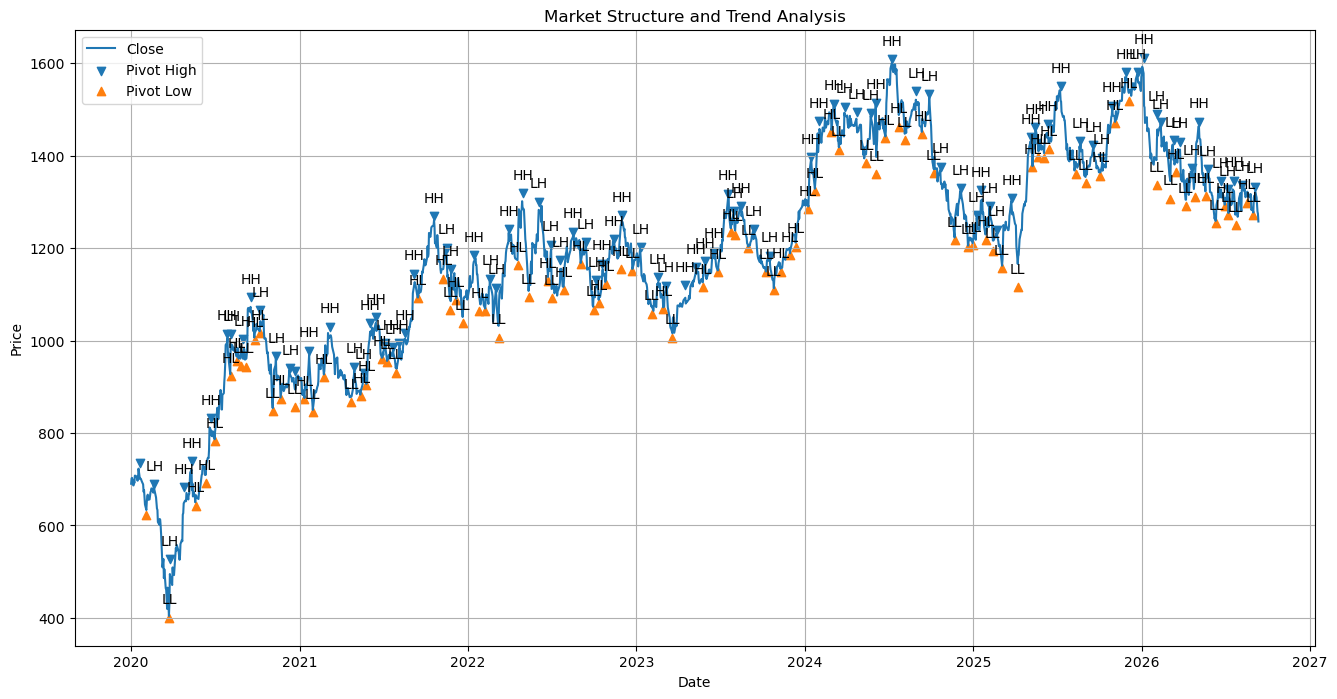

In [7]:
# =====================================================
# STEP 4 : MARKET STRUCTURE AND TREND ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

print("\nStarting Market Structure Analysis...\n")

# =====================================================
# SWING HIGH DETECTION
# =====================================================

swing_length = 5

data["PivotHigh"] = np.nan
data["PivotLow"] = np.nan

for i in range(swing_length, len(data) - swing_length):

    current_high = data["High"].iloc[i]

    left_highs = data["High"].iloc[
        i-swing_length:i
    ]

    right_highs = data["High"].iloc[
        i+1:i+swing_length+1
    ]

    if (
        current_high > left_highs.max()
        and
        current_high >= right_highs.max()
    ):
        data.loc[
            data.index[i],
            "PivotHigh"
        ] = current_high

# =====================================================
# SWING LOW DETECTION
# =====================================================

for i in range(swing_length, len(data) - swing_length):

    current_low = data["Low"].iloc[i]

    left_lows = data["Low"].iloc[
        i-swing_length:i
    ]

    right_lows = data["Low"].iloc[
        i+1:i+swing_length+1
    ]

    if (
        current_low < left_lows.min()
        and
        current_low <= right_lows.min()
    ):
        data.loc[
            data.index[i],
            "PivotLow"
        ] = current_low

print("Pivot High / Low Detection Completed")

# =====================================================
# HH HL LH LL
# =====================================================

data["HH"] = False
data["HL"] = False
data["LH"] = False
data["LL"] = False

data["Structure"] = ""

previous_high = np.nan
previous_low = np.nan

for i in range(len(data)):

    # -------------------------
    # Pivot High
    # -------------------------

    if not pd.isna(
        data["PivotHigh"].iloc[i]
    ):

        current_high = (
            data["PivotHigh"].iloc[i]
        )

        if not pd.isna(previous_high):

            if current_high > previous_high:

                data.loc[
                    data.index[i],
                    "HH"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "HH"

            elif current_high < previous_high:

                data.loc[
                    data.index[i],
                    "LH"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "LH"

        previous_high = current_high

    # -------------------------
    # Pivot Low
    # -------------------------

    if not pd.isna(
        data["PivotLow"].iloc[i]
    ):

        current_low = (
            data["PivotLow"].iloc[i]
        )

        if not pd.isna(previous_low):

            if current_low > previous_low:

                data.loc[
                    data.index[i],
                    "HL"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "HL"

            elif current_low < previous_low:

                data.loc[
                    data.index[i],
                    "LL"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "LL"

        previous_low = current_low

print("HH HL LH LL Classification Completed")

# =====================================================
# TREND DIRECTION
# =====================================================

data["Trend"] = "Range"

for i in range(len(data)):

    if (
        data["HH"].iloc[i]
        and
        data["HL"].iloc[i]
    ):
        data.loc[
            data.index[i],
            "Trend"
        ] = "Bullish"

    elif (
        data["LH"].iloc[i]
        and
        data["LL"].iloc[i]
    ):
        data.loc[
            data.index[i],
            "Trend"
        ] = "Bearish"

print("Trend Direction Completed")

# =====================================================
# MARKET CONTROL
# =====================================================

data["Market_Control"] = "Neutral"

data.loc[
    data["Trend"] == "Bullish",
    "Market_Control"
] = "Buyers"

data.loc[
    data["Trend"] == "Bearish",
    "Market_Control"
] = "Sellers"

print("Market Control Completed")

# =====================================================
# HTF BIAS
# =====================================================

data["EMA50"] = (
    data["Close"]
    .ewm(span=50, adjust=False)
    .mean()
)

data["EMA200"] = (
    data["Close"]
    .ewm(span=200, adjust=False)
    .mean()
)

data["HTF_Bias"] = np.where(
    data["EMA50"] > data["EMA200"],
    "Bullish",
    "Bearish"
)

print("HTF Bias Completed")

# =====================================================
# LATEST MARKET STATUS
# =====================================================

latest = data.iloc[-1]

print("\n================================")

print("Date :", latest["Date"])

print("Trend :", latest["Trend"])

print(
    "Market Control :",
    latest["Market_Control"]
)

print(
    "HTF Bias :",
    latest["HTF_Bias"]
)

print("================================")

# =====================================================
# SAVE DATASET
# =====================================================

data.to_csv(
    "market_structure_analysis.csv",
    index=False
)

print(
    "\nmarket_structure_analysis.csv Saved"
)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(16,8))

plt.plot(
    data["Date"],
    data["Close"],
    label="Close"
)

pivot_highs = data[
    data["PivotHigh"].notna()
]

pivot_lows = data[
    data["PivotLow"].notna()
]

plt.scatter(
    pivot_highs["Date"],
    pivot_highs["PivotHigh"],
    marker="v",
    label="Pivot High"
)

plt.scatter(
    pivot_lows["Date"],
    pivot_lows["PivotLow"],
    marker="^",
    label="Pivot Low"
)

for _, row in data.iterrows():

    if row["Structure"] != "":

        y = (
            row["High"]
            if row["Structure"]
            in ["HH", "LH"]
            else row["Low"]
        )

        plt.annotate(
            row["Structure"],
            (row["Date"], y),
            xytext=(0,10),
            textcoords="offset points",
            ha="center"
        )

plt.title(
    "Market Structure and Trend Analysis"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()